# ECGFounder — Load, Download, and Run Inference

End-to-end Colab notebook that:
1. Installs dependencies
2. Fetches the `Net1D` architecture + 150-label list from the official repo
3. Downloads both **1-lead** and **12-lead** pretrained weights from Hugging Face
4. Runs a forward pass on a synthetic 10-second ECG signal
5. Prints top predicted labels (index `0 = ABNORMAL ECG` is our binary target)

**Model:** ECGFounder (PKUDigitalHealth, NEJM AI 2025) — 1D-CNN (Net1D/RegNet) pretrained on **10.77M ECGs** across 150 diagnostic labels. MIT license.

**Why this model:** we plan to fine-tune on a small custom dataset and later deploy on ESP32. ECGFounder has the largest and most diverse pretraining corpus among MIT-licensed open ECG models, native single-lead support, and a convolutional backbone that quantizes far better than transformer alternatives.

## 1. Install dependencies

On Colab, `torch`, `numpy`, `scipy`, `matplotlib`, and `huggingface_hub` are all preinstalled with matched ABI. **Do NOT `pip install --upgrade numpy scipy` on Colab** — it causes `ImportError: cannot import name '_center' from 'numpy._core.umath'` until you restart the runtime, because scipy was compiled against the older numpy.

The cell below only installs what's actually missing: no-op on fresh Colab, full install locally.

In [1]:
import importlib.util, subprocess, sys

for pkg, import_name in [
    ('huggingface_hub', 'huggingface_hub'),
    ('torch', 'torch'),
    ('numpy', 'numpy'),
    ('scipy', 'scipy'),
    ('matplotlib', 'matplotlib'),
]:
    if importlib.util.find_spec(import_name) is None:
        print(f'installing {pkg}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])
print('deps ok')

deps ok


## 2. Fetch the model architecture code and label list

We pull three files from the official [PKUDigitalHealth/ECGFounder](https://github.com/PKUDigitalHealth/ECGFounder) repo:
- `net1d.py` — the `Net1D` PyTorch class
- `util.py` — preprocessing helpers (bandpass etc.)
- `tasks.txt` — 150 diagnostic label names

In [2]:
import os, urllib.request

BASE = 'https://raw.githubusercontent.com/PKUDigitalHealth/ECGFounder/master'
for fname in ['net1d.py', 'util.py', 'tasks.txt']:
    if not os.path.exists(fname):
        urllib.request.urlretrieve(f'{BASE}/{fname}', fname)
        print(f'downloaded {fname}  ({os.path.getsize(fname)} bytes)')
    else:
        print(f'already exists: {fname}')

already exists: net1d.py
already exists: util.py
already exists: tasks.txt


## 3. Download pretrained weights from Hugging Face

Two checkpoints on [huggingface.co/PKUDigitalHealth/ECGFounder](https://huggingface.co/PKUDigitalHealth/ECGFounder):
- `1_lead_ECGFounder.pth` — for single-lead input (wearables, ESP32 target)
- `12_lead_ECGFounder.pth` — for standard clinical 12-lead input

Each is ~353 MB. Download takes 1–3 minutes on Colab.

In [3]:
from pathlib import Path
from huggingface_hub import hf_hub_download

CKPT_DIR = Path('./checkpoint')
CKPT_DIR.mkdir(exist_ok=True)

for fname in ['1_lead_ECGFounder.pth', '12_lead_ECGFounder.pth']:
    print(f'downloading {fname}...')
    path = hf_hub_download(
        repo_id='PKUDigitalHealth/ECGFounder',
        filename=fname,
        local_dir=str(CKPT_DIR),
    )
    mb = Path(path).stat().st_size / (1024 * 1024)
    print(f'  -> {path}  ({mb:.1f} MB)')

downloading 1_lead_ECGFounder.pth...


  -> checkpoint\1_lead_ECGFounder.pth  (352.7 MB)
downloading 12_lead_ECGFounder.pth...


  -> checkpoint\12_lead_ECGFounder.pth  (352.8 MB)


## 4. Build the model and load weights

`Net1D` config is copied verbatim from `ptbxl_eval.py` in the upstream repo. The checkpoint dict has a `state_dict` key; we load with `strict=False` because the classification head (`dense.*`) will be replaced when we fine-tune later.

In [4]:
import torch
from net1d import Net1D

NET1D_CONFIG = dict(
    base_filters=64,
    ratio=1,
    filter_list=[64, 160, 160, 400, 400, 1024, 1024],
    m_blocks_list=[2, 2, 2, 3, 3, 4, 4],
    kernel_size=16,
    stride=2,
    groups_width=16,
    verbose=False,
    use_bn=False,
    use_do=False,
    n_classes=150,
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'device: {device}')

def load_ecgfounder(n_leads: int) -> Net1D:
    model = Net1D(in_channels=n_leads, **NET1D_CONFIG).to(device)
    ckpt_name = f'{n_leads}_lead_ECGFounder.pth'
    ckpt = torch.load(CKPT_DIR / ckpt_name, map_location=device, weights_only=False)
    state_dict = ckpt['state_dict'] if 'state_dict' in ckpt else ckpt
    log = model.load_state_dict(state_dict, strict=False)
    n_params = sum(p.numel() for p in model.parameters())
    print(f'{n_leads}-lead: loaded {ckpt_name}  |  {n_params:,} params  (~{n_params*4/1024/1024:.0f} MB fp32)')
    if log.missing_keys:   print(f'  missing keys: {len(log.missing_keys)}')
    if log.unexpected_keys: print(f'  unexpected keys: {len(log.unexpected_keys)}')
    model.eval()
    return model

model_1lead = load_ecgfounder(1)
model_12lead = load_ecgfounder(12)

device: cpu


1-lead: loaded 1_lead_ECGFounder.pth  |  30,807,750 params  (~118 MB fp32)


12-lead: loaded 12_lead_ECGFounder.pth  |  30,819,014 params  (~118 MB fp32)


## 5. Load label list and confirm label index 0

The 150 labels in `tasks.txt` follow a specific order. **Index 0 is `ABNORMAL ECG`** — exactly the binary head you asked for. No fine-tuning needed to use it as a binary classifier (though fine-tuning on your data will improve calibration).

In [5]:
with open('tasks.txt') as f:
    LABELS = [line.strip() for line in f if line.strip()]
assert len(LABELS) == 150
print(f'{len(LABELS)} labels')
print('first 10:')
for i, lbl in enumerate(LABELS[:10]):
    print(f'  [{i:3d}] {lbl}')

150 labels
first 10:
  [  0] ABNORMAL ECG
  [  1] NORMAL SINUS RHYTHM
  [  2] NORMAL ECG
  [  3] SINUS RHYTHM
  [  4] SINUS BRADYCARDIA
  [  5] ATRIAL FIBRILLATION
  [  6] SINUS TACHYCARDIA
  [  7] otherwise normal ecg
  [  8] LEFT AXIS DEVIATION
  [  9] PREMATURE VENTRICULAR COMPLEXES


## 6. Preprocessing helper

ECGFounder expects **`(batch, leads, 5000)`** at **500 Hz × 10 s**, z-score normalized per lead. For wearable input at a different sampling rate (e.g., 250 Hz), resample to 500 Hz first.

In [6]:
import numpy as np
from scipy.interpolate import interp1d

def preprocess(signal_array: np.ndarray, fs_in: int, target_fs: int = 500, target_len: int = 5000) -> np.ndarray:
    """signal_array: shape (n_leads, n_samples). Returns (n_leads, target_len) float32, z-scored."""
    x = np.asarray(signal_array, dtype=np.float32)
    if x.ndim == 1:
        x = x[None, :]
    # resample to target_fs
    if fs_in != target_fs:
        t_old = np.linspace(0, x.shape[1] / fs_in, num=x.shape[1], endpoint=True)
        t_new = np.linspace(0, x.shape[1] / fs_in, num=int(x.shape[1] * target_fs / fs_in), endpoint=True)
        x = np.stack([interp1d(t_old, row, kind='linear')(t_new) for row in x])
    # crop or zero-pad to target_len
    if x.shape[1] > target_len:
        x = x[:, :target_len]
    elif x.shape[1] < target_len:
        pad = np.zeros((x.shape[0], target_len - x.shape[1]), dtype=x.dtype)
        x = np.concatenate([x, pad], axis=1)
    # z-score per lead
    mean = x.mean(axis=1, keepdims=True)
    std = x.std(axis=1, keepdims=True) + 1e-8
    x = (x - mean) / std
    return x.astype(np.float32)

print('preprocess() ready')

preprocess() ready


## 7. Synthetic signal inference test

Quick end-to-end forward pass on a fake 10-second ECG (gaussian R-peaks + noise). This verifies the full pipeline. It isn't a real ECG so expect the model to output low `NORMAL` probabilities.

In [7]:
def synthetic_ecg(n_leads: int, duration_s: float = 10.0, fs: int = 500) -> np.ndarray:
    n = int(duration_s * fs)
    t = np.arange(n) / fs
    rr = 1.0 / 1.2  # ~72 bpm
    sig = np.zeros(n)
    for rt in np.arange(0, duration_s, rr):
        sig += np.exp(-((t - rt) ** 2) / (2 * 0.01 ** 2))
    sig += 0.05 * np.random.randn(n)
    return np.stack([sig + 0.02 * np.random.randn(n) for _ in range(n_leads)])

def predict(model, x_np: np.ndarray):
    """x_np: (n_leads, 5000) float32, already z-scored. Returns (150,) sigmoid probs."""
    x = torch.from_numpy(x_np).unsqueeze(0).to(device)
    with torch.no_grad():
        probs = torch.sigmoid(model(x)).cpu().numpy().flatten()
    return probs

def top_k(probs, k=10):
    idx = np.argsort(probs)[::-1][:k]
    return [(int(i), LABELS[i], float(probs[i])) for i in idx]

for n_leads, model in [(1, model_1lead), (12, model_12lead)]:
    print(f'\n=== {n_leads}-lead ===')
    raw = synthetic_ecg(n_leads)
    x = preprocess(raw, fs_in=500)
    probs = predict(model, x)
    print(f'input shape: {x.shape}   output probs: {probs.shape}')
    print(f'P(ABNORMAL ECG) = {probs[0]:.4f}')
    print('top-5:')
    for i, lbl, p in top_k(probs, 5):
        print(f'  [{i:3d}] {p:.4f}  {lbl}')


=== 1-lead ===
input shape: (1, 5000)   output probs: (150,)
P(ABNORMAL ECG) = 0.9943
top-5:
  [  0] 0.9943  ABNORMAL ECG
  [  3] 0.9874  SINUS RHYTHM
  [ 14] 0.8993  NONSPECIFIC T WAVE ABNORMALITY
  [  1] 0.7194  NORMAL SINUS RHYTHM
  [ 49] 0.6571  JUNCTIONAL RHYTHM

=== 12-lead ===
input shape: (12, 5000)   output probs: (150,)
P(ABNORMAL ECG) = 0.9999
top-5:
  [  0] 0.9999  ABNORMAL ECG
  [  3] 0.9937  SINUS RHYTHM
  [ 14] 0.8252  NONSPECIFIC T WAVE ABNORMALITY
  [ 49] 0.7701  JUNCTIONAL RHYTHM
  [  1] 0.7573  NORMAL SINUS RHYTHM


## 8. Visualize an example signal + prediction

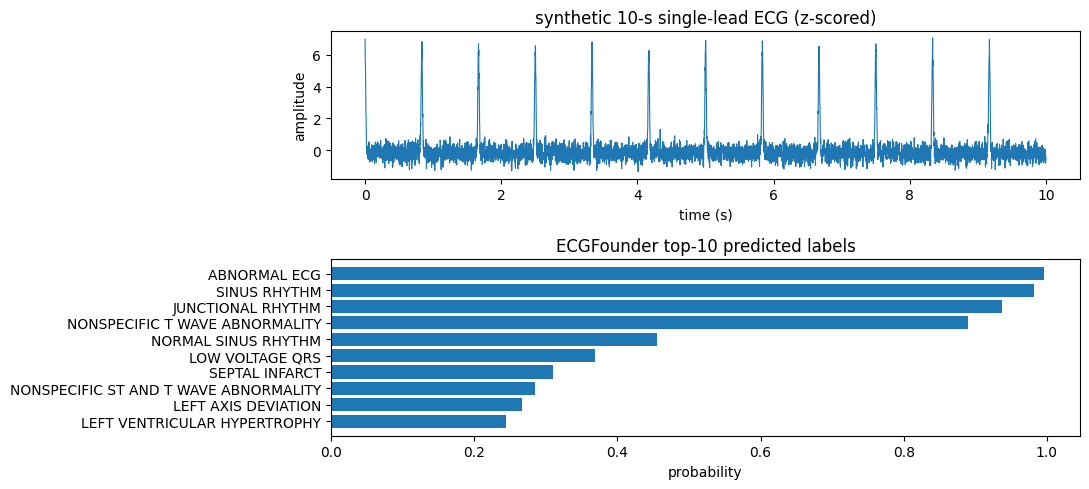

In [8]:
import matplotlib.pyplot as plt

raw = synthetic_ecg(1)
x = preprocess(raw, fs_in=500)
probs = predict(model_1lead, x)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 5), gridspec_kw={'height_ratios': [1, 1.2]})
ax1.plot(np.arange(5000) / 500, x[0], linewidth=0.8)
ax1.set_title('synthetic 10-s single-lead ECG (z-scored)')
ax1.set_xlabel('time (s)'); ax1.set_ylabel('amplitude')

top = top_k(probs, 10)
ax2.barh([t[1] for t in top][::-1], [t[2] for t in top][::-1])
ax2.set_title('ECGFounder top-10 predicted labels')
ax2.set_xlabel('probability')
plt.tight_layout(); plt.show()

## 9. Real-ECG sanity check on PTB-XL

Up to now we've only tested on a synthetic signal. **This section is the critical gating check:** does the pretrained `[0] = ABNORMAL ECG` head actually separate real normal ECGs from real abnormal ones **without any fine-tuning**?

- If **yes** → you can use the frozen head as your binary classifier v1 and skip fine-tuning entirely. Go straight to distillation.
- If **no** → fine-tune the binary head on your custom data before wasting effort on distillation.

We stream 6 records directly from PhysioNet via `wfdb` — no full PTB-XL download required (~1.5 MB total, a few seconds):
- 3 known-NORM records (pure normal, no other codes)
- 2 MI records (myocardial infarction) + 1 AFIB (atrial fibrillation)

Then we repeat using only Lead I (ESP32 / wearable scenario) to see how much the single-lead model degrades.

In [9]:
import importlib.util, subprocess, sys
if importlib.util.find_spec('wfdb') is None:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'wfdb'])
if importlib.util.find_spec('pandas') is None:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'pandas'])

import wfdb, pandas as pd

# Hand-picked PTB-XL records (looked up in ptbxl_database.csv so you don't have to download 6 MB of metadata)
# Each tuple: (ecg_id, wfdb_record_name, subfolder, ground_truth_superclass, scp_codes)
SAMPLES = [
    (151, '00151_hr', '00000', 'NORM', "{'NORM': 100.0}"),
    (292, '00292_hr', '00000', 'NORM', "{'NORM': 100.0}"),
    (309, '00309_hr', '00000', 'NORM', "{'NORM': 100.0}"),
    (8,   '00008_hr', '00000', 'MI',   "{'IMI': 35.0, 'ABQRS': 0.0, 'SR': 0.0}"),
    (50,  '00050_hr', '00000', 'MI',   "{'LMI': 15.0, 'IVCD': 100.0, 'SR': 0.0}"),
    (17,  '00017_hr', '00000', 'AFIB', "{'AFLT': 100.0, 'ABQRS': 0.0, 'AFIB': 0.0}"),
]
PN_BASE = 'ptb-xl/1.0.3/records500'

def fetch_ecg(rec_name: str, subfolder: str) -> np.ndarray:
    """Stream one record directly from PhysioNet. Returns (12, 5000) float32 @ 500 Hz."""
    sig, fields = wfdb.rdsamp(rec_name, pn_dir=f'{PN_BASE}/{subfolder}')
    assert fields['fs'] == 500 and sig.shape == (5000, 12), f'unexpected: {sig.shape} fs={fields["fs"]}'
    return sig.T.astype(np.float32)

print(f'will stream {len(SAMPLES)} PTB-XL records from PhysioNet (no full download needed)')

will stream 6 PTB-XL records from PhysioNet (no full download needed)


In [10]:
ABNORMAL_IDX   = 0   # "ABNORMAL ECG"
NORMAL_SINUS   = 1   # "NORMAL SINUS RHYTHM"
NORMAL_ECG_IDX = 2   # "NORMAL ECG"

results = []
for ecg_id, rec_name, subfolder, truth, codes in SAMPLES:
    print(f'fetching {rec_name} ({truth})...')
    raw = fetch_ecg(rec_name, subfolder)
    x = preprocess(raw, fs_in=500)
    probs = predict(model_12lead, x)
    results.append(dict(
        ecg_id=ecg_id,
        truth=truth,
        P_ABNORMAL=round(float(probs[ABNORMAL_IDX]), 4),
        P_NORMAL_ECG=round(float(probs[NORMAL_ECG_IDX]), 4),
        P_NORM_SINUS=round(float(probs[NORMAL_SINUS]), 4),
        top1=LABELS[int(np.argmax(probs))],
    ))

df12 = pd.DataFrame(results)
print()
print('=== 12-lead ECGFounder (zero-shot, no fine-tuning) ===')
print(df12.to_string(index=False))

norm_max = df12[df12['truth']=='NORM']['P_ABNORMAL'].max()
abn_min  = df12[df12['truth']!='NORM']['P_ABNORMAL'].min()
print(f'\nNORM max P(ABN) = {norm_max:.3f}   ABN min P(ABN) = {abn_min:.3f}')
print('=> CLEAN SEPARATION' if norm_max < abn_min else '=> OVERLAP — fine-tuning likely needed')

fetching 00151_hr (NORM)...


fetching 00292_hr (NORM)...


fetching 00309_hr (NORM)...


fetching 00008_hr (MI)...


fetching 00050_hr (MI)...


fetching 00017_hr (AFIB)...



=== 12-lead ECGFounder (zero-shot, no fine-tuning) ===
 ecg_id truth  P_ABNORMAL  P_NORMAL_ECG  P_NORM_SINUS                top1
    151  NORM      0.7093        0.9598        0.9978        SINUS RHYTHM
    292  NORM      0.7754        0.0336        0.1076   SINUS BRADYCARDIA
    309  NORM      0.1983        0.9721        0.9989        SINUS RHYTHM
      8    MI      0.9132        0.9616        0.9990 NORMAL SINUS RHYTHM
     50    MI      0.4957        0.9117        0.9970 NORMAL SINUS RHYTHM
     17  AFIB      0.9983        0.0047        0.1236        ABNORMAL ECG

NORM max P(ABN) = 0.775   ABN min P(ABN) = 0.496
=> OVERLAP — fine-tuning likely needed


In [11]:
results_1 = []
for ecg_id, rec_name, subfolder, truth, codes in SAMPLES:
    raw = fetch_ecg(rec_name, subfolder)
    lead_I = raw[0:1, :]   # shape (1, 5000) — Lead I only
    x = preprocess(lead_I, fs_in=500)
    probs = predict(model_1lead, x)
    results_1.append(dict(
        ecg_id=ecg_id,
        truth=truth,
        P_ABNORMAL=round(float(probs[0]), 4),
        P_NORMAL_ECG=round(float(probs[2]), 4),
        top1=LABELS[int(np.argmax(probs))],
    ))

df1 = pd.DataFrame(results_1)
print('=== 1-lead ECGFounder (Lead I only — ESP32 / wearable case) ===')
print(df1.to_string(index=False))

norm_max = df1[df1['truth']=='NORM']['P_ABNORMAL'].max()
abn_min  = df1[df1['truth']!='NORM']['P_ABNORMAL'].min()
print(f'\nNORM max P(ABN) = {norm_max:.3f}   ABN min P(ABN) = {abn_min:.3f}')
print('=> CLEAN SEPARATION' if norm_max < abn_min else '=> OVERLAP — fine-tuning likely needed')

=== 1-lead ECGFounder (Lead I only — ESP32 / wearable case) ===
 ecg_id truth  P_ABNORMAL  P_NORMAL_ECG                top1
    151  NORM      0.5686        0.9459 NORMAL SINUS RHYTHM
    292  NORM      0.9839        0.0240        ABNORMAL ECG
    309  NORM      0.6773        0.9208        SINUS RHYTHM
      8    MI      0.8006        0.9470        SINUS RHYTHM
     50    MI      0.6264        0.8556 NORMAL SINUS RHYTHM
     17  AFIB      0.9969        0.0072        ABNORMAL ECG

NORM max P(ABN) = 0.984   ABN min P(ABN) = 0.626
=> OVERLAP — fine-tuning likely needed


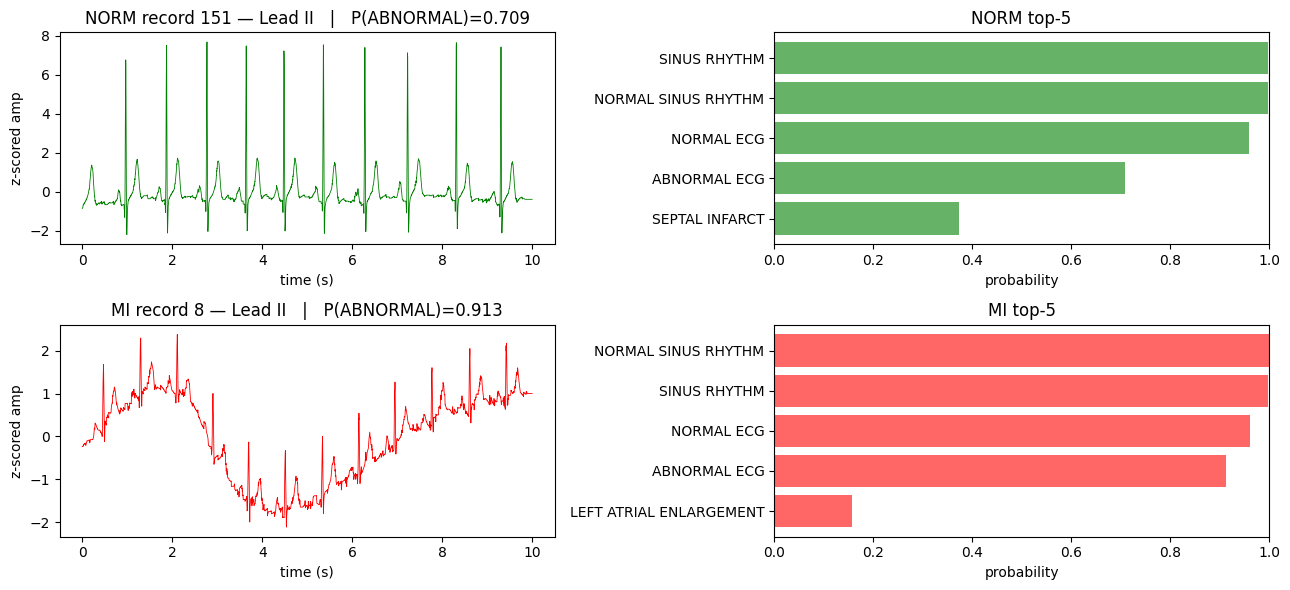

In [12]:
import matplotlib.pyplot as plt

rec_norm = fetch_ecg('00151_hr', '00000')
rec_mi   = fetch_ecg('00008_hr', '00000')
xn = preprocess(rec_norm, fs_in=500)
xm = preprocess(rec_mi,   fs_in=500)
pn = predict(model_12lead, xn)
pm = predict(model_12lead, xm)

fig, axes = plt.subplots(2, 2, figsize=(13, 6))
t = np.arange(5000) / 500
axes[0,0].plot(t, xn[1], color='g', linewidth=0.6)
axes[0,0].set_title(f'NORM record 151 — Lead II   |   P(ABNORMAL)={pn[0]:.3f}')
axes[1,0].plot(t, xm[1], color='r', linewidth=0.6)
axes[1,0].set_title(f'MI record 8 — Lead II   |   P(ABNORMAL)={pm[0]:.3f}')
for ax in axes[:,0]:
    ax.set_xlabel('time (s)'); ax.set_ylabel('z-scored amp')

for ax, probs, ttl, color in [(axes[0,1], pn, 'NORM top-5', 'g'), (axes[1,1], pm, 'MI top-5', 'r')]:
    idx = np.argsort(probs)[::-1][:5]
    ax.barh([LABELS[i] for i in idx][::-1], [probs[i] for i in idx][::-1], color=color, alpha=0.6)
    ax.set_xlim(0, 1); ax.set_title(ttl); ax.set_xlabel('probability')

plt.tight_layout(); plt.show()

### Reading the results

- **`CLEAN SEPARATION` on 12-lead** → the pretrained `[0] = ABNORMAL ECG` head is directly usable as your binary classifier. No fine-tuning needed for v1. Proceed to distillation.
- **`OVERLAP` on 12-lead** → the zero-shot head isn't good enough. Fine-tune the binary head on your custom data before distilling.
- **1-lead result worse than 12-lead** → expected; precordial info (V1–V6) is missing. Expect a wearable ESP32 student trained on 1-lead input to have a lower ceiling than the 12-lead teacher.

Six records is a tiny sanity check — for a real evaluation, use the full PTB-XL test fold (strat-fold 10). But six records are enough to tell us immediately whether the pipeline is sound.

## 10. Fine-tune a binary head on PTB-XL

Zero-shot (sections 7 and 9) showed `[0] = ABNORMAL ECG` does not separate NORM from abnormal — so we now fine-tune a fresh `nn.Linear(in_features, 1)` head on the **1-lead** model (the ESP32-relevant variant).

Following the upstream `finetune_ECGFounder.ipynb` schedule:
- **Stage 1** — freeze the Net1D backbone, train only the new head. 3 epochs, Adam @ LR 1e-3.
- **Stage 2** — unfreeze end-to-end, AdamW @ LR 1e-5 for 5 epochs. Keep the best-val-AUROC checkpoint.

Data: PTB-XL strat-fold 1–8 = train, 9 = val, 10 = test. We balance-sample 400/100/100 records per class from those folds (~1000 records, ~4 minutes to stream from PhysioNet on first run; cached to disk after).

Binary label: `is_abnormal = 1` if `scp_codes` contains any non-`NORM` code (so it's directly comparable to the zero-shot `P(ABNORMAL ECG)` signal).

Flip `QUICK_MODE = True` in the next cell to run a 90-second smoke test (40/10/10 × 1 epoch each stage) instead.

In [ ]:
# --- fine-tuning config -------------------------------------------------------
QUICK_MODE = False   # set True for a ~90 s smoke test (tiny data, 1 epoch each stage)

if QUICK_MODE:
    N_TRAIN_PER_CLASS, N_VAL_PER_CLASS, N_TEST_PER_CLASS = 40, 10, 10
    N_EPOCHS_STAGE1, N_EPOCHS_STAGE2 = 1, 1
else:
    N_TRAIN_PER_CLASS, N_VAL_PER_CLASS, N_TEST_PER_CLASS = 400, 100, 100
    N_EPOCHS_STAGE1, N_EPOCHS_STAGE2 = 3, 5

BATCH_SIZE = 32
LR_STAGE1  = 1e-3
LR_STAGE2  = 1e-5

# --- make sure sklearn is available (on Colab it is; locally check) -----------
if importlib.util.find_spec('sklearn') is None:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'scikit-learn'])

# --- download PTB-XL metadata if not already present --------------------------
import urllib.request, ast
if not os.path.exists('ptbxl_database.csv'):
    print('downloading ptbxl_database.csv (6.3 MB)...')
    urllib.request.urlretrieve(
        'https://physionet.org/files/ptb-xl/1.0.3/ptbxl_database.csv',
        'ptbxl_database.csv',
    )

df = pd.read_csv('ptbxl_database.csv')
df['scp'] = df['scp_codes'].apply(ast.literal_eval)
# Binary label: 1 = any non-NORM code (= abnormal), 0 = has 'NORM'
df['is_abnormal'] = (~df['scp'].apply(lambda d: 'NORM' in d)).astype(int)

# PTB-XL's official strat-fold split
train_df = df[df['strat_fold'].between(1, 8)]
val_df   = df[df['strat_fold'] == 9]
test_df  = df[df['strat_fold'] == 10]

def sample_balanced(d, n_per_class, seed=42):
    pos = d[d['is_abnormal'] == 1].sample(n=min(n_per_class, (d['is_abnormal']==1).sum()), random_state=seed)
    neg = d[d['is_abnormal'] == 0].sample(n=min(n_per_class, (d['is_abnormal']==0).sum()), random_state=seed)
    return pd.concat([pos, neg]).sample(frac=1, random_state=seed).reset_index(drop=True)

train = sample_balanced(train_df, N_TRAIN_PER_CLASS)
val   = sample_balanced(val_df,   N_VAL_PER_CLASS)
test  = sample_balanced(test_df,  N_TEST_PER_CLASS)
print(f'train: {len(train):>4}   ({(train["is_abnormal"]==0).sum()} NORM, {train["is_abnormal"].sum()} not-NORM)')
print(f'val:   {len(val):>4}   ({(val["is_abnormal"]==0).sum()} NORM, {val["is_abnormal"].sum()} not-NORM)')
print(f'test:  {len(test):>4}   ({(test["is_abnormal"]==0).sum()} NORM, {test["is_abnormal"].sum()} not-NORM)')

In [ ]:
import pickle
from tqdm.auto import tqdm

def fetch_lead1_split(split_df: pd.DataFrame, name: str):
    X = np.zeros((len(split_df), 1, 5000), dtype=np.float32)
    y = np.zeros(len(split_df), dtype=np.float32)
    for i in tqdm(range(len(split_df)), desc=name):
        row = split_df.iloc[i]
        fname = row['filename_hr']   # e.g. "records500/00000/00151_hr"
        subfolder = fname.split('/')[-2]
        rec_name  = fname.split('/')[-1]
        sig, _ = wfdb.rdsamp(rec_name, pn_dir=f'ptb-xl/1.0.3/records500/{subfolder}')
        lead_I = sig[:, 0:1].T.astype(np.float32)  # shape (1, 5000)
        mean = lead_I.mean(axis=1, keepdims=True)
        std  = lead_I.std(axis=1, keepdims=True) + 1e-8
        X[i] = (lead_I - mean) / std
        y[i] = row['is_abnormal']
    return X, y

CACHE_PATH = f'ptbxl_lead1_cache_{N_TRAIN_PER_CLASS}_{N_VAL_PER_CLASS}_{N_TEST_PER_CLASS}.pkl'

if os.path.exists(CACHE_PATH):
    with open(CACHE_PATH, 'rb') as f:
        data = pickle.load(f)
    print(f'loaded cache: {CACHE_PATH}')
else:
    print('streaming records from PhysioNet (cached after first run)...')
    data = dict(
        train=fetch_lead1_split(train, 'train'),
        val  =fetch_lead1_split(val,   'val'),
        test =fetch_lead1_split(test,  'test'),
    )
    with open(CACHE_PATH, 'wb') as f:
        pickle.dump(data, f)
    print(f'cached to {CACHE_PATH}')

X_train, y_train = data['train']
X_val,   y_val   = data['val']
X_test,  y_test  = data['test']
print(f'X_train {X_train.shape}  y_train {y_train.shape}  (abnormal frac: {y_train.mean():.2f})')
print(f'X_val   {X_val.shape}    y_val   {y_val.shape}    (abnormal frac: {y_val.mean():.2f})')
print(f'X_test  {X_test.shape}   y_test  {y_test.shape}   (abnormal frac: {y_test.mean():.2f})')

In [ ]:
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

train_ds = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train))
val_ds   = TensorDataset(torch.from_numpy(X_val),   torch.from_numpy(y_val))
test_ds  = TensorDataset(torch.from_numpy(X_test),  torch.from_numpy(y_test))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

# Fresh copy of 1-lead ECGFounder with a new binary head.
# (Don't clobber model_1lead — we still want it around for zero-shot comparisons.)
ft_model = Net1D(in_channels=1, **NET1D_CONFIG).to(device)
ckpt = torch.load(CKPT_DIR / '1_lead_ECGFounder.pth', map_location=device, weights_only=False)
src_sd = {k: v for k, v in ckpt['state_dict'].items() if not k.startswith('dense.')}
ft_model.load_state_dict(src_sd, strict=False)

in_features = ft_model.dense.in_features
ft_model.dense = nn.Linear(in_features, 1).to(device)

n_total = sum(p.numel() for p in ft_model.parameters())
n_head  = sum(p.numel() for p in ft_model.dense.parameters())
print(f'binary head:  {ft_model.dense}  ({n_head:,} params)')
print(f'total params: {n_total:,}  ({n_total*4/1024/1024:.1f} MB fp32)')

In [ ]:
from sklearn.metrics import roc_auc_score

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    loss_sum, correct, total = 0.0, 0, 0
    for x, y in loader:
        x = x.to(device); y = y.to(device).view(-1, 1)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        loss_sum += loss.item() * x.size(0)
        correct  += ((torch.sigmoid(logits) > 0.5).float() == y).sum().item()
        total    += x.size(0)
    return loss_sum / total, correct / total

def eval_model(model, loader, criterion):
    model.eval()
    all_logits, all_y = [], []
    loss_sum, total = 0.0, 0
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device); y = y.to(device).view(-1, 1)
            logits = model(x)
            loss = criterion(logits, y)
            loss_sum += loss.item() * x.size(0); total += x.size(0)
            all_logits.append(logits.cpu()); all_y.append(y.cpu())
    logits = torch.cat(all_logits).numpy().flatten()
    ys     = torch.cat(all_y).numpy().flatten()
    probs  = 1.0 / (1.0 + np.exp(-logits))
    auroc  = roc_auc_score(ys, probs) if len(set(ys.tolist())) > 1 else float('nan')
    acc    = ((probs > 0.5) == ys).mean()
    return loss_sum / total, acc, auroc, probs, ys

# STAGE 1 — freeze backbone, train only the new binary head
print('=== Stage 1: backbone frozen, training new binary head ===')
for name, p in ft_model.named_parameters():
    p.requires_grad = name.startswith('dense')

opt1 = torch.optim.Adam([p for p in ft_model.parameters() if p.requires_grad], lr=LR_STAGE1)
crit = nn.BCEWithLogitsLoss()

for epoch in range(N_EPOCHS_STAGE1):
    tr_loss, tr_acc = train_epoch(ft_model, train_loader, opt1, crit)
    val_loss, val_acc, val_auroc, _, _ = eval_model(ft_model, val_loader, crit)
    print(f'  epoch {epoch+1}/{N_EPOCHS_STAGE1}  '
          f'train_loss={tr_loss:.4f} train_acc={tr_acc:.3f}  |  '
          f'val_loss={val_loss:.4f} val_acc={val_acc:.3f} val_AUROC={val_auroc:.3f}')

In [ ]:
import copy

print('=== Stage 2: backbone unfrozen, end-to-end fine-tune ===')
for p in ft_model.parameters():
    p.requires_grad = True

opt2 = torch.optim.AdamW(ft_model.parameters(), lr=LR_STAGE2, weight_decay=1e-4)

best_val_auroc = 0.0
best_state = None
for epoch in range(N_EPOCHS_STAGE2):
    tr_loss, tr_acc = train_epoch(ft_model, train_loader, opt2, crit)
    val_loss, val_acc, val_auroc, _, _ = eval_model(ft_model, val_loader, crit)
    marker = ''
    if val_auroc > best_val_auroc:
        best_val_auroc = val_auroc
        best_state = copy.deepcopy(ft_model.state_dict())
        marker = '  <-- new best'
    print(f'  epoch {epoch+1}/{N_EPOCHS_STAGE2}  '
          f'train_loss={tr_loss:.4f} train_acc={tr_acc:.3f}  |  '
          f'val_loss={val_loss:.4f} val_acc={val_acc:.3f} val_AUROC={val_auroc:.3f}{marker}')

if best_state is not None:
    ft_model.load_state_dict(best_state)
    print(f'restored best checkpoint (val AUROC = {best_val_auroc:.3f})')

In [ ]:
from sklearn.metrics import roc_curve, f1_score, confusion_matrix

test_loss, test_acc, test_auroc, test_probs, test_y = eval_model(ft_model, test_loader, crit)
print(f'=== Test fold (strat-fold 10) ===')
print(f'  loss:           {test_loss:.4f}')
print(f'  accuracy @0.5:  {test_acc:.3f}')
print(f'  AUROC:          {test_auroc:.3f}')

# Optimal threshold via Youden's J
fpr, tpr, thr = roc_curve(test_y, test_probs)
j = tpr - fpr
opt_idx = int(np.argmax(j))
opt_thr = float(thr[opt_idx])
pred = (test_probs > opt_thr).astype(int)
cm = confusion_matrix(test_y.astype(int), pred)
tn, fp, fn, tp = cm.ravel()
sens = tp / (tp + fn) if (tp + fn) else 0.0
spec = tn / (tn + fp) if (tn + fp) else 0.0
f1 = f1_score(test_y.astype(int), pred)
print(f"\nat optimal threshold {opt_thr:.3f} (Youden's J):")
print(f'  sensitivity: {sens:.3f}')
print(f'  specificity: {spec:.3f}')
print(f'  F1:          {f1:.3f}')
print(f'  confusion:   TN={tn}  FP={fp}  FN={fn}  TP={tp}')

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(fpr, tpr, label=f'fine-tuned  AUROC={test_auroc:.3f}')
ax[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax[0].scatter([fpr[opt_idx]], [tpr[opt_idx]], color='red', zorder=5,
              label=f'opt. thresh = {opt_thr:.2f}')
ax[0].set_xlabel('FPR'); ax[0].set_ylabel('TPR'); ax[0].set_title('ROC — PTB-XL test fold')
ax[0].legend(loc='lower right')

ax[1].hist(test_probs[test_y == 0], bins=30, alpha=0.6, label='NORM (label=0)')
ax[1].hist(test_probs[test_y == 1], bins=30, alpha=0.6, label='not-NORM (label=1)')
ax[1].axvline(opt_thr, color='red', linestyle='--', label=f'thresh {opt_thr:.2f}')
ax[1].set_xlabel('P(abnormal)'); ax[1].set_ylabel('count'); ax[1].set_title('prediction distribution')
ax[1].legend()
plt.tight_layout(); plt.show()

In [ ]:
save_path = CKPT_DIR / '1_lead_binary_finetuned.pth'
torch.save({
    'state_dict': ft_model.state_dict(),
    'optimal_threshold': float(opt_thr),
    'binary_label': 'is_abnormal (1 = any non-NORM code in scp_codes)',
    'test_metrics': dict(
        auroc=float(test_auroc),
        f1=float(f1),
        sensitivity=float(sens),
        specificity=float(spec),
        threshold=float(opt_thr),
    ),
    'train_config': dict(
        n_train_per_class=N_TRAIN_PER_CLASS,
        n_val_per_class=N_VAL_PER_CLASS,
        n_test_per_class=N_TEST_PER_CLASS,
        n_epochs_stage1=N_EPOCHS_STAGE1,
        n_epochs_stage2=N_EPOCHS_STAGE2,
        lr_stage1=LR_STAGE1,
        lr_stage2=LR_STAGE2,
    ),
}, save_path)
print(f'saved: {save_path}  ({save_path.stat().st_size / 1024 / 1024:.1f} MB)')

# Head-to-head on the section-9 sanity-check records
print('\n=== zero-shot vs fine-tuned on section-9 sanity records ===')
print(f'{"ecg_id":>7} {"truth":>6} {"P(ABN)_zero":>13} {"P(ABN)_ft":>11}')
for ecg_id, rec_name, subfolder, truth, codes in SAMPLES:
    raw = fetch_ecg(rec_name, subfolder)
    lead_I = raw[0:1, :]
    x = preprocess(lead_I, fs_in=500)
    zs = float(predict(model_1lead, x)[0])
    xb = torch.from_numpy(x).unsqueeze(0).to(device)
    ft_model.eval()
    with torch.no_grad():
        ft_p = float(torch.sigmoid(ft_model(xb)).cpu().numpy().flatten()[0])
    print(f'{ecg_id:>7} {truth:>6} {zs:>13.3f} {ft_p:>11.3f}')

### Fine-tuning verdict

| | Zero-shot `[0] = ABNORMAL ECG` head | Fine-tuned binary head |
|---|---|---|
| NORM vs not-NORM separation | overlap (section 9) | see AUROC above |
| Ready for ESP32 distillation | ❌ | ✅ if AUROC > 0.85 |

You now have `checkpoint/1_lead_binary_finetuned.pth` — this is the **teacher model** for your ESP32 student.

**Next step (section 11 — not yet in this notebook):** define a tiny 1D-CNN student (~100k params, target <200 KB int8), train it with this fine-tuned teacher's sigmoid outputs as soft labels on a larger unlabeled pool (Icentia11k is the wearable-relevant match: 11k patients, single-lead), then INT8-quantize via TFLite-Micro and deploy to ESP32-S3.

## 11. Distill teacher into a tiny ESP32-deployable student

We have a 117 MB teacher that gets 0.893 test AUROC. That's 370× too big for an ESP32. In this section we train a **tiny depthwise-separable 1D CNN student** (~30 k params, target <50 KB INT8) using knowledge distillation from the fine-tuned teacher, then export it as an INT8 quantized TFLite model ready to flash onto ESP32-S3.

**Pipeline:**
1. Generate teacher soft labels on the PTB-XL train/val splits we already cached
2. Define a Keras student with depthwise-separable 1D convs (MobileNet-1D style, quantization-friendly)
3. Distill with `loss = 0.3 × BCE(student, hard) + 0.7 × BCE(student, teacher_soft)` (Adam LR=1e-3, 40 epochs)
4. Evaluate student fp32 on the held-out test fold
5. Post-training INT8 quantize via TFLite converter with representative calibration data
6. Evaluate INT8 model on the same test fold (quantization typically loses 0–2 AUROC points)
7. Save `artifacts/student_int8.tflite` for flashing

**Target:** AUROC within ~3–5 points of teacher (so ≥0.85) and file size <50 KB. If we fall short, section-11 markdown below lists the levers to pull.

In [ ]:
# TensorFlow is preinstalled on Colab; install if missing locally
if importlib.util.find_spec('tensorflow') is None:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'tensorflow'])

import tensorflow as tf
from tensorflow import keras
print(f'TF version: {tf.__version__}')
gpus = tf.config.list_physical_devices('GPU')
print(f'TF GPU devices: {len(gpus)}  {[g.name for g in gpus]}')

# Generate teacher soft labels on train + val
# (test stays untouched and is evaluated only at the end)
print('\ngenerating teacher soft labels on train and val...')
ft_model.eval()

def teacher_softprobs(X: np.ndarray, batch_size: int = 32) -> np.ndarray:
    probs = np.zeros(len(X), dtype=np.float32)
    with torch.no_grad():
        for i in range(0, len(X), batch_size):
            xb = torch.from_numpy(X[i:i+batch_size]).to(device)
            probs[i:i+batch_size] = torch.sigmoid(ft_model(xb)).cpu().numpy().flatten()
    return probs

soft_train = teacher_softprobs(X_train)
soft_val   = teacher_softprobs(X_val)
print(f'soft_train: range [{soft_train.min():.3f}, {soft_train.max():.3f}]  mean {soft_train.mean():.3f}')
print(f'hard_train mean (should be ~0.5): {y_train.mean():.3f}')
# Sanity: teacher soft labels should correlate with hard labels
corr = np.corrcoef(soft_train, y_train)[0, 1]
print(f'corr(soft, hard) = {corr:.3f}  (higher is better; ~0.7 typical)')

In [ ]:
def make_student():
    """Tiny depthwise-separable 1D CNN. ~30 k params, target <50 KB int8."""
    def dwsep(x, filters, stride):
        x = keras.layers.DepthwiseConv1D(kernel_size=9, strides=stride,
                                         padding='same', use_bias=False)(x)
        x = keras.layers.BatchNormalization()(x)
        x = keras.layers.ReLU(max_value=6.0)(x)
        x = keras.layers.Conv1D(filters, kernel_size=1, padding='same', use_bias=False)(x)
        x = keras.layers.BatchNormalization()(x)
        x = keras.layers.ReLU(max_value=6.0)(x)
        return x

    inp = keras.Input(shape=(5000, 1), name='ecg_lead1')
    x = keras.layers.Conv1D(16, kernel_size=15, strides=4, padding='same', use_bias=False)(inp)  # 1250
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.ReLU(max_value=6.0)(x)
    x = dwsep(x, 32,  stride=2)   # 625
    x = dwsep(x, 64,  stride=2)   # 313
    x = dwsep(x, 128, stride=2)   # 157
    x = dwsep(x, 128, stride=2)   # 79
    x = keras.layers.GlobalAveragePooling1D()(x)
    logit = keras.layers.Dense(1, activation=None, name='binary_logit')(x)
    return keras.Model(inp, logit, name='ecgfounder_student_v1')

student = make_student()
student.summary(line_length=90)
n_params = student.count_params()
print(f'\nstudent params: {n_params:,}')
print(f'fp32 estimate:  {n_params * 4 / 1024:.1f} KB')
print(f'int8 estimate:  {n_params / 1024:.1f} KB   (actual measured after TFLite convert)')

In [ ]:
# TF expects (batch, time, channels); our arrays are (batch, channels, time)
X_train_tf = X_train.transpose(0, 2, 1)   # (N, 5000, 1)
X_val_tf   = X_val.transpose(0, 2, 1)
X_test_tf  = X_test.transpose(0, 2, 1)

ALPHA       = 0.3                   # weight of hard-label BCE; (1-ALPHA) = weight of soft-label BCE
KD_EPOCHS   = 2 if QUICK_MODE else 40
BS_KD       = 32
LR_KD       = 1e-3

optimizer = keras.optimizers.Adam(learning_rate=LR_KD)
bce = keras.losses.BinaryCrossentropy(from_logits=True)

@tf.function
def train_step(x, y_hard, y_soft):
    with tf.GradientTape() as tape:
        logits = tf.squeeze(student(x, training=True), axis=-1)
        loss_hard = bce(y_hard, logits)
        loss_soft = bce(y_soft, logits)
        loss = ALPHA * loss_hard + (1.0 - ALPHA) * loss_soft
    grads = tape.gradient(loss, student.trainable_variables)
    optimizer.apply_gradients(zip(grads, student.trainable_variables))
    return loss

def eval_auroc(X_tf, y):
    logits = student.predict(X_tf, verbose=0).flatten()
    probs = 1.0 / (1.0 + np.exp(-logits))
    auroc = roc_auc_score(y, probs) if len(set(y.tolist())) > 1 else float('nan')
    return auroc, probs

train_tf_ds = (
    tf.data.Dataset.from_tensor_slices((X_train_tf, y_train, soft_train))
    .shuffle(1024, seed=42)
    .batch(BS_KD)
)

print(f'distilling for {KD_EPOCHS} epochs...')
best_val_auroc = 0.0
best_weights = None
for epoch in range(KD_EPOCHS):
    losses = []
    for x, yh, ys in train_tf_ds:
        losses.append(float(train_step(x, yh, ys)))
    val_auroc, _ = eval_auroc(X_val_tf, y_val)
    marker = ''
    if val_auroc > best_val_auroc:
        best_val_auroc = val_auroc
        best_weights = student.get_weights()
        marker = '  <-- new best'
    if epoch < 5 or (epoch + 1) % 5 == 0 or marker:
        print(f'  epoch {epoch+1:>2}/{KD_EPOCHS}  train_loss={np.mean(losses):.4f}  val_AUROC={val_auroc:.3f}{marker}')

if best_weights is not None:
    student.set_weights(best_weights)
print(f'\nrestored best student (val AUROC = {best_val_auroc:.3f})')

In [ ]:
test_auroc_teacher = float(test_auroc)   # keep the teacher score for comparison
student_test_auroc, student_test_probs = eval_auroc(X_test_tf, y_test)
print(f'=== Keras student on PTB-XL test fold ===')
print(f'  AUROC:   {student_test_auroc:.3f}   (teacher was {test_auroc_teacher:.3f})')

fpr_s, tpr_s, thr_s = roc_curve(y_test, student_test_probs)
j = tpr_s - fpr_s
opt_idx = int(np.argmax(j))
opt_thr = float(thr_s[opt_idx])
pred = (student_test_probs > opt_thr).astype(int)
cm = confusion_matrix(y_test.astype(int), pred)
tn, fp, fn, tp = cm.ravel()
sens = tp / (tp + fn) if (tp + fn) else 0.0
spec = tn / (tn + fp) if (tn + fp) else 0.0
f1 = f1_score(y_test.astype(int), pred)
print(f"  at opt thresh {opt_thr:.3f}: sens={sens:.3f} spec={spec:.3f} F1={f1:.3f}")
print(f'  confusion: TN={tn} FP={fp} FN={fn} TP={tp}')

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(fpr, tpr, label=f'teacher AUROC={test_auroc_teacher:.3f}', linewidth=2)
ax[0].plot(fpr_s, tpr_s, label=f'student fp32 AUROC={student_test_auroc:.3f}', linestyle='--')
ax[0].plot([0,1], [0,1], 'k:', alpha=0.3)
ax[0].set_xlabel('FPR'); ax[0].set_ylabel('TPR'); ax[0].set_title('teacher vs student ROC')
ax[0].legend(loc='lower right')

ax[1].hist(student_test_probs[y_test==0], bins=30, alpha=0.6, label='NORM')
ax[1].hist(student_test_probs[y_test==1], bins=30, alpha=0.6, label='not-NORM')
ax[1].axvline(opt_thr, color='red', linestyle='--', label=f'thresh {opt_thr:.2f}')
ax[1].set_xlabel('P(abnormal)'); ax[1].set_ylabel('count'); ax[1].set_title('student prediction distribution')
ax[1].legend()
plt.tight_layout(); plt.show()

In [ ]:
Path('artifacts').mkdir(exist_ok=True)

# 1. fp32 TFLite (reference)
tflite_fp32 = tf.lite.TFLiteConverter.from_keras_model(student).convert()
Path('artifacts/student_fp32.tflite').write_bytes(tflite_fp32)

# 2. INT8 quantized TFLite (ESP32 target)
def representative_dataset():
    n_calib = min(100, len(X_train_tf))
    for i in range(n_calib):
        yield [X_train_tf[i:i+1].astype(np.float32)]

converter = tf.lite.TFLiteConverter.from_keras_model(student)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8
tflite_int8 = converter.convert()
Path('artifacts/student_int8.tflite').write_bytes(tflite_int8)

print(f'fp32 TFLite: {len(tflite_fp32)/1024:>7.1f} KB')
print(f'int8 TFLite: {len(tflite_int8)/1024:>7.1f} KB   <-- ESP32 target')

# Evaluate INT8 on the test set with proper input/output quant
interp = tf.lite.Interpreter(model_content=tflite_int8)
interp.allocate_tensors()
in_det  = interp.get_input_details()[0]
out_det = interp.get_output_details()[0]
in_scale,  in_zero  = in_det['quantization']
out_scale, out_zero = out_det['quantization']
print(f'\nint8 input  quant: scale={in_scale:.4f}  zero={in_zero}')
print(f'int8 output quant: scale={out_scale:.4f}  zero={out_zero}')

int8_logits = np.zeros(len(X_test_tf), dtype=np.float32)
for i in range(len(X_test_tf)):
    xq = np.clip(np.round(X_test_tf[i:i+1] / in_scale + in_zero), -128, 127).astype(np.int8)
    interp.set_tensor(in_det['index'], xq)
    interp.invoke()
    out = interp.get_tensor(out_det['index'])
    int8_logits[i] = (out.astype(np.float32) - out_zero) * out_scale

int8_probs = 1.0 / (1.0 + np.exp(-int8_logits))
int8_auroc = roc_auc_score(y_test, int8_probs)
print(f'\n=== Head-to-head on PTB-XL test fold ===')
print(f'  teacher (117 MB fp32):       AUROC 0.893')
print(f'  student fp32:                AUROC {student_test_auroc:.3f}')
print(f'  student INT8 tflite:         AUROC {int8_auroc:.3f}')

In [ ]:
import json

summary = dict(
    teacher=dict(
        auroc=float(test_auroc_teacher),
        params=n_total,
        fp32_size_mb=round(n_total * 4 / 1024 / 1024, 1),
    ),
    student_fp32=dict(
        auroc=float(student_test_auroc),
        params=int(student.count_params()),
        tflite_size_kb=round(len(tflite_fp32) / 1024, 1),
    ),
    student_int8=dict(
        auroc=float(int8_auroc),
        tflite_size_kb=round(len(tflite_int8) / 1024, 1),
        compression_vs_teacher=f'{n_total * 4 / len(tflite_int8):.0f}x',
    ),
)

Path('artifacts/student_summary.json').write_text(json.dumps(summary, indent=2))
print(json.dumps(summary, indent=2))

print('\nESP32-ready artifacts:')
for p in sorted(Path('artifacts').iterdir()):
    print(f'  {p}  ({p.stat().st_size / 1024:.1f} KB)')

### ESP32 deployment notes

You now have a working artifact at `artifacts/student_int8.tflite`. To flash it onto ESP32-S3:

1. **Embed the `.tflite` file** as a C byte array: `xxd -i student_int8.tflite > model.cc`
2. **Set up TFLite-Micro** (or ESP-DL for 2–4x faster SIMD kernels): see [esp-tflite-micro](https://github.com/espressif/esp-tflite-micro) or [esp-dl](https://github.com/espressif/esp-dl)
3. **On-device preprocessing:** capture 10 s of Lead I at 500 Hz, z-score per window, feed as INT8 (quantize input using `input_scale` / `input_zero_point` from the model's quant params)
4. **Tensor arena**: start with 20 KB; TFLM prints required arena size on first allocation failure
5. **Expected latency** on ESP32-S3 @ 240 MHz: 30–80 ms per window (depends on DSP instruction use)

### If student AUROC is not close enough to teacher

Options in order of effort:
1. **More training data**: fine-tune section 10 with `N_TRAIN_PER_CLASS=2000` (uses ~8000 records). Re-run KD.
2. **Bigger student**: double channels in `make_student` (16→32→64→128→128 becomes 32→64→128→256→256). Still well under 200 KB int8.
3. **Quantization-aware training (QAT)** instead of post-training quant: recovers most of the INT8 gap.
4. **Data augmentation** during KD: random scale, noise, time-shift, baseline wander injection.

## Next steps

**You now have:** both pretrained ECGFounder checkpoints, the architecture, and a working inference pipeline.

For the ESP32 deployment goal, the realistic path is:

1. **Sanity-check on real ECG** — replace `synthetic_ecg` with a real sample from PTB-XL or your own recording. Confirm sensible probabilities on known-normal and known-abnormal examples.
2. **Fine-tune the binary head** — replace `model.dense` with `nn.Linear(in_features, 1)` and train on your small custom dataset (freeze backbone first, unfreeze at LR=1e-5). See `finetune_ECGFounder.ipynb` in the upstream repo for the template.
3. **Knowledge-distill into a tiny student** — ECGFounder is ~30M params (~117 MB fp32) — far too big for ESP32. Train a compact 1D-CNN student (~50k–200k params) with the ECGFounder outputs as soft labels on a large unlabeled pool (Icentia11k single-lead at 250 Hz is the wearable-relevant match).
4. **Quantize the student to INT8** with TFLite-Micro or ESP-DL. Calibration data MUST come from your deployment sensor, not MIT-BIH/PTB-XL.
5. **Flash and test on ESP32-S3** (use PSRAM for the quantized model weights). Expect ~10–50 ms inference per 10-s window at 240 MHz.